# 4. Strategy C backtest: crypto funding carry

**Rule (fixed before testing).** Every Sunday, rank tradable coins by their trailing 7-day average funding. **Short the top third, long the bottom third**, equal weights, dollar-neutral (each leg = 50% of capital). Daily P&L per coin = side x price return - side x funding paid (a short *receives* positive funding). Costs: 5 bp per unit traded. In-sample 2020-2023, out-of-sample from 2024.

Same functions as `code/04_backtest_strategyC.py`.

## What this notebook does

**Purpose.** Test Strategy C, a crypto funding carry trade. Coins with high funding are crowded leveraged longs; shorting them collects the funding, while going long the low-funding coins hedges the overall crypto market. Same functions as `code/04_backtest_strategyC.py`.

**Data** (from notebook 03): daily closing prices, traded volume and daily funding for 12 coins (USDC excluded).

**Steps**
1. **Tradable coins.** A coin can be traded on a day only if it has a price and positive volume (this removes LUNA after 2022-05 and FTT after 2022-11-14). At least 6 tradable coins are required.
2. **Signal.** Average daily funding over the last 7 days, using data up to the day before.
3. **Portfolio.** Every Sunday: short the top third of coins by funding and long the bottom third, equal weights, each leg 50% of capital (dollar-neutral). A coin that stops trading during the week is closed.
4. **P&L.** For each coin: side x price return - side x funding paid; a short position receives positive funding. Costs of 5 bp per unit traded.
5. **Results.** Performance (in-sample 2020-2023, out-of-sample from 2024, annualised with 365 days), split into funding vs price, worst weeks, and robustness to the lookback (3, 7, 30 days) and rebalancing (daily, weekly).

All parameters were fixed before the backtest was run.

**Outputs** (when the script is run): `output/strategyC/performance_table.csv`, `daily_returns.csv`, `weights.csv`, `return_decomposition.csv`, `worst_weeks.csv`, `robustness_grid.csv` and `strategyC_performance.png`.

In [1]:
# Setup: run everything from the project root so the scripts' relative paths work
import os, importlib.util
from pathlib import Path
if Path.cwd().name == "notebooks":
    os.chdir("..")
print("Working directory:", Path.cwd())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
%matplotlib inline

def load_script(path, name):
    """Import a numbered script from code/ (file names starting with a digit can't be imported normally)."""
    spec = importlib.util.spec_from_file_location(name, path)
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod

Working directory: /Users/reza/Desktop/mfe-term_3/currency_market/currency-crypto-carry


In [2]:
C = load_script("code/04_backtest_strategyC.py", "stratC")
print("Coins:", C.COINS, "| lookback:", C.LOOKBACK, "days | rebalance:", C.REBALANCE,
      "| min coins:", C.MIN_COINS, "| cost:", C.TC_BP, "bp")

Coins: ['BTC', 'ETH', 'BNB', 'XRP', 'ADA', 'DOGE', 'SOL', 'LTC', 'LINK', 'AVAX', 'LUNA', 'FTT'] | lookback: 7 days | rebalance: W | min coins: 6 | cost: 5.0 bp


## Step 1 - data, returns and the tradable mask

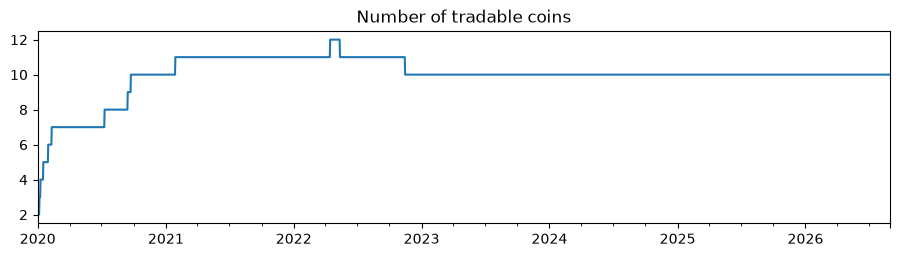

In [3]:
close, volume, funding = C.load()
ret = close.pct_change(fill_method=None)
tradable = close.notna() & volume.gt(0)
tradable.sum(axis=1).plot(figsize=(11, 2.5), title="Number of tradable coins"); plt.show()

## Step 2 - signal and weights

In [4]:
w = C.carry_weights(funding, tradable, C.LOOKBACK, C.REBALANCE)
print("Latest positions:")
w.iloc[-1][w.iloc[-1] != 0].sort_values().to_frame("weight")

Latest positions:


,weight
BTC,-0.166667
DOGE,-0.166667
LTC,-0.166667
BNB,0.166667
ADA,0.166667
SOL,0.166667


## Step 3 - backtest

In [5]:
bt = C.backtest(w, ret, funding, C.TC_BP)
series = {"Crypto carry (gross)": bt["gross"], "Crypto carry (net)": bt["net"]}
C.split_table(series, bt["turnover"]).round(2)

Start         End  Days Ann. mean (%) Ann. vol (%)    Sharpe Max drawdown (%) Skewness (weekly) Worst week (%) Hit rate days (%) Ann. turnover (x)
Crypto carry (gross) Full           2020-02-03  2026-08-31  2402      6.376221    29.873648   0.21344       -65.975044          1.272226     -27.229936         51.540383         44.801901
                     In-sample      2020-02-03  2023-12-31  1428     -0.248589    36.047402 -0.006896       -65.975044          1.231647     -27.229936         50.210084         45.369398
                     Out-of-sample  2024-01-01  2026-08-31   974     16.088982    17.205819   0.93509        -13.27564         -0.466301      -9.181408          53.49076         43.969884
Crypto carry (net)   Full           2020-02-03  2026-08-31  2402      4.128528    29.873002  0.138203       -67.324732          1.273162     -27.263086         51.248959         44.801901
                     In-sample      2020-02-03  2023-12-31  1428     -2.517059    36.045579  -0.06983       -67.324732          1.232452     -27.263086         49.789916         45.369398
                     Out-of-sample  2024-01-01  2026-08-31   974      13.87175    17.208576  0.806095       -13.347716         -0.459161      -9.211365          53.38809         43.969884

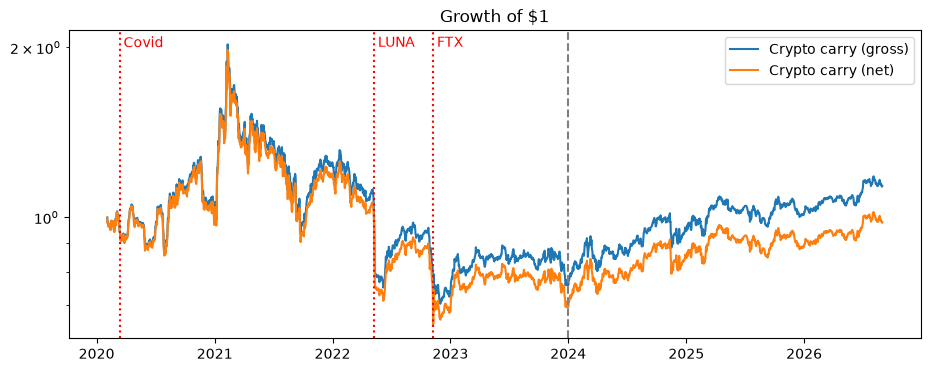

In [6]:
fig, ax = plt.subplots(figsize=(11, 4))
for name, r in series.items():
    ax.plot((1 + r).cumprod(), label=name)
for d, lab in (("2020-03-12", "Covid"), ("2022-05-09", "LUNA"), ("2022-11-08", "FTX")):
    ax.axvline(pd.Timestamp(d), color="red", ls=":"); ax.text(pd.Timestamp(d), ax.get_ylim()[1], " " + lab, color="red", va="top")
ax.axvline(pd.Timestamp(C.IN_SAMPLE_END), color="grey", ls="--")
ax.set_yscale("log"); ax.legend(); ax.set_title("Growth of $1"); plt.show()

## Step 4 - where does the return come from?
Funding received vs price moves of the positions.

,Funding (% p.a.),Price (% p.a.),Costs (% p.a.),Net (% p.a.)
Full,8.55,-2.17,-2.25,4.13
In-sample,12.26,-12.51,-2.27,-2.52
Out-of-sample,3.10,12.99,-2.22,13.87


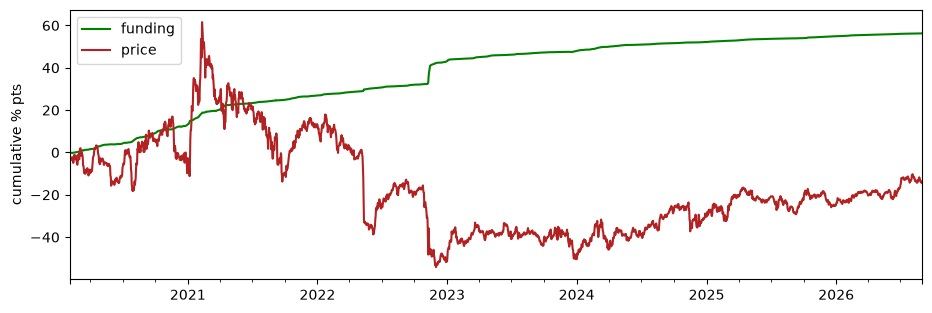

In [7]:
rows = {}
for pname, (a, b) in C.periods().items():
    rows[pname] = {"Funding (% p.a.)": 100 * 365 * bt["carry"].loc[a:b].mean(),
                   "Price (% p.a.)": 100 * 365 * bt["price"].loc[a:b].mean(),
                   "Costs (% p.a.)": 100 * 365 * (bt["net"] - bt["gross"]).loc[a:b].mean(),
                   "Net (% p.a.)": 100 * 365 * bt["net"].loc[a:b].mean()}
display(pd.DataFrame(rows).T.round(2))
ax = (100 * bt["carry"].cumsum()).plot(figsize=(11, 3.5), label="funding", color="green")
(100 * bt["price"].cumsum()).plot(ax=ax, label="price", color="firebrick")
ax.set_ylabel("cumulative % pts"); ax.legend(); plt.show()

## Step 5 - worst weeks

In [8]:
wk = (1 + bt["net"]).resample("W-SUN").prod() - 1
(100 * wk.nsmallest(5)).round(2).to_frame("net return (%)")

,net return (%)
2022-05-15,-27.26
2021-09-12,-12.28
2022-11-13,-11.62
2020-11-29,-11.04
2021-08-15,-10.02


## Step 6 - robustness: lookback x rebalancing
Computed live here (takes a few seconds).

In [9]:
grid = []
for lb in (3, 7, 30):
    for rb in ("D", "W"):
        b = C.backtest(C.carry_weights(funding, tradable, lb, rb), ret, funding, C.TC_BP)
        oos = b["net"].loc[pd.Timestamp(C.IN_SAMPLE_END) + pd.Timedelta(days=1):]
        grid.append({"lookback": lb, "rebalance": rb, "Sharpe gross": C.perf(b["gross"])["Sharpe"],
                     "Sharpe net": C.perf(b["net"])["Sharpe"], "Sharpe OOS": C.perf(oos)["Sharpe"],
                     "MaxDD (%)": C.perf(b["net"])["Max drawdown (%)"]})
pd.DataFrame(grid).round(2)

,lookback,rebalance,Sharpe gross,Sharpe net,Sharpe OOS,MaxDD (%)
0,3,D,0.88,0.68,0.41,-40.48
1,3,W,0.55,0.49,1.29,-61.17
2,7,D,0.68,0.56,0.92,-59.74
3,7,W,0.21,0.14,0.81,-67.32
4,30,D,0.32,0.28,0.83,-73.31
5,30,W,0.10,0.07,0.42,-82.23


The pre-specified case (7 days, weekly) is reported as the main result; we do not switch to the best row after seeing it.

## Questions this notebook answers, and results

**1. Does crypto funding carry make money?** A little, and unevenly. From 2020-02-03 to 2026-08-31, net of costs: 4.1% a year with 29.9% volatility, **Sharpe 0.14**, maximum drawdown -67%, worst week -27.3%.
- In-sample (2020-2023): -2.5% a year, Sharpe -0.07.
- Out-of-sample (2024-2026): **13.9% a year, Sharpe 0.81**, maximum drawdown -13%.
- Turnover is about 45x a year; costs take about 2.2% a year.

**2. Where does the return come from?** The funding is real: **+8.6% a year** over the full sample (+12.3% in-sample, +3.1% out-of-sample). But price moves of the positions cost -12.5% a year in-sample, as the shorted crowded coins kept rallying, and added +13.0% a year out-of-sample. So the recent strong result is mostly price, not funding.

**3. When does it lose money?**

| Week ending | Net return |
|---|---|
| 2022-05-15 (LUNA collapse) | -27.3% |
| 2021-09-12 | -12.3% |
| 2022-11-13 (FTX collapse) | -11.6% |
| 2020-11-29 | -11.0% |
| 2021-08-15 | -10.0% |

In the LUNA week the strategy was *long* LUNA: its funding had turned negative because traders were shorting it, so the rule put it in the long leg just before it lost about 99%.

**4. Is the result robust?** It depends on the settings. Net Sharpe is 0.68 (3 days, daily), 0.49 (3 days, weekly), 0.56 (7 days, daily), **0.14 (7 days, weekly: our pre-specified case)**, 0.28 (30 days, daily) and 0.07 (30 days, weekly). Shorter signals and faster rebalancing work better even after costs, so the information in funding seems to fade within days. We keep the pre-specified case as the main result.

**5. What does the portfolio hold now?** As of 2026-08-31: short BTC, DOGE and LTC, long BNB, ADA and SOL (1/6 each).

**Limitations**
- Short sample (about 6.5 years), and the in-sample period is dominated by the 2021 bull market and the 2022 collapses.
- Only 12 coins, so each leg holds just 3-4 coins and single-coin events dominate.
- Costs are a flat 5 bp; slippage in stressed markets, funding caps and exchange risk are not modelled.